In [1]:
import sys 
from minusface import MinusBackbone
model = MinusBackbone(mode='stage1')
import torch
ckpt_path = "../../../../minusface_stage1.pth"
model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))

/home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [2]:
def preprocess_image(image_path, size=112, norm=True):
    from PIL import Image
    from torchvision import transforms

    input_image = Image.open(image_path).convert('RGB')
    if norm:
        preprocess = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
        ])
    else:
        preprocess = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
        ])   
    input_tensor = preprocess(input_image)
    input_batch = input_tensor.unsqueeze(0)  # Create a mini-batch as expected by the model
    return input_batch

In [3]:
from PIL import Image
import numpy as np
def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked

In [4]:
model = model.eval()
model = model.to('cuda')

In [5]:
def get_another_image(df, img_name):
    row = df[df["img_name"] == img_name]
    if row.empty:
        return None 
    id_val = row["id"].iloc[0]
    imgs = df[df["id"] == id_val]["img_name"].tolist()
    imgs = [x for x in imgs if x != img_name]
    return imgs[0] if imgs else None

In [6]:
import pandas as pd
import random 
df = pd.read_csv('/path/to/Identity_CelebA.txt', sep=' ')
df.columns = ["col0","img_name","id"]

def get_another_image(df, img_name):
    row = df[df["img_name"] == img_name]
    if row.empty:
        return None
    id_val = row["id"].iloc[0]
    imgs = df[df["id"] == id_val]["img_name"].tolist()
    imgs = [x for x in imgs if x != img_name]
    if not imgs:
        return None
    return random.choice(imgs)


In [7]:
all_root = '/path/to/celeba_aligned'

In [8]:
images = "val"
from PIL import Image
import os
import tqdm
os.makedirs("shuffled_val_another", exist_ok=True) 
os.makedirs("shuffled_val", exist_ok=True) 
# for filename in tqdm.tqdm(os.listdir(images)): 
#     img_path = f"{images}/{filename}"
#     another_img = get_another_image(df, filename)
#     if another_img is None: 
#         continue
#     with torch.no_grad(): 
#         res = model(preprocess_image(img_path).to("cuda"))
#     shuffled = res[5].detach().cpu()[0].permute(1, 2, 0).numpy()
#     shuffled = (shuffled - shuffled.min()) / (shuffled.max() - shuffled.min())
#     shuffled = shuffled * 255
#     shuffled = shuffled.astype('uint8')
#     Image.fromarray(shuffled).save(f"shuffled_val/{filename}") 

#     with torch.no_grad(): 
#         res = model(preprocess_image(f"{all_root}/{another_img}").to("cuda"))
#     shuffled = res[5].detach().cpu()[0].permute(1, 2, 0).numpy()
#     shuffled = (shuffled - shuffled.min()) / (shuffled.max() - shuffled.min())
#     shuffled = shuffled * 255
#     shuffled = shuffled.astype('uint8')
#     Image.fromarray(shuffled).save(f"shuffled_val_another/{filename}") 

In [9]:
from facenet_pytorch import InceptionResnetV1
import torch

device = "cuda:1" if torch.cuda.is_available() else "cpu"

teacher = InceptionResnetV1(pretrained='vggface2').eval().to(device)

student = InceptionResnetV1(pretrained='vggface2').to(device)
state = torch.load("vgg_student.pth", map_location=device)
student.load_state_dict(state)
student = student.eval()

In [10]:
img_path = f"val/{os.listdir(images)[39]}" 
another_path = get_another_image(df, os.path.basename(img_path))

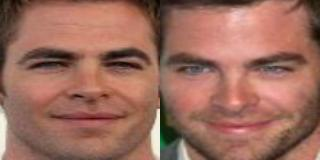

In [11]:
hstack([Image.open(img_path), Image.open(f"{all_root}/{another_path}")])

In [12]:
embedding_1 = teacher(preprocess_image(img_path, size=160).to("cuda:1"))
embedding_2 = teacher(preprocess_image(f"{all_root}/{another_path}", size=160).to("cuda:1"))
embedding_1 @ embedding_2.T

tensor([[0.8812]], device='cuda:1', grad_fn=<MmBackward0>)

In [13]:
len(os.listdir("shuffled_val")), len(os.listdir(images))

(5061, 5145)

In [14]:
# shuffled_features_list = []
# shuffled_features_another_list = []
# original_features_list = []
# original_features_another_list = []
# import tqdm
# for image_name in tqdm.tqdm(os.listdir("shuffled_val")): 
#     with torch.no_grad(): 
#         shuffled_features = student(preprocess_image(f"shuffled_val/{image_name}", size=160).to("cuda"))
#         shuffled_features_another = student(preprocess_image(f"shuffled_val_another/{image_name}", size=160).to("cuda"))
#         original_features = teacher(preprocess_image(f"{images}/{image_name}", size=160).to("cuda"))
#         original_another = get_another_image(df, image_name)
#         original_features_another = teacher(preprocess_image(f"{all_root}/{original_another}", size=160).to("cuda"))
        
#     shuffled_features_list.append(shuffled_features.detach().cpu())
#     shuffled_features_another_list.append(shuffled_features_another.detach().cpu())
#     original_features_list.append(original_features.detach().cpu())
#     original_features_another_list.append(original_features_another.detach().cpu())

In [15]:
from torchvision import transforms
tf_student = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
])


def convert_batch(conv_raw):
    conv_raw = conv_raw.to(device)
    with torch.no_grad():
        out = model(conv_raw)
    out = out[5]
    out = out.permute(0,2,3,1).cpu().numpy()
    out = (out - out.min(axis=(1,2,3),keepdims=True)) / (out.max(axis=(1,2,3),keepdims=True) - out.min(axis=(1,2,3),keepdims=True) + 1e-8)
    out = np.clip(out[...,:3],0,1)
    out = (out*255).astype(np.uint8)
    imgs = [Image.fromarray(x) for x in out]
    final = torch.stack([tf_student(im) for im in imgs]).to(device)
    return final

In [16]:
shuffled_features_list = []
shuffled_features_another_list = []
original_features_list = []
original_features_another_list = []

import tqdm
batch_stu = []
batch_tea = []
batch_tea_another = []
for image_name in tqdm.tqdm(os.listdir("shuffled_val")): 
    with torch.no_grad(): 
        batch_stu.append(preprocess_image(f"val/{image_name}").to("cuda:1"))
        batch_tea.append(preprocess_image(f"{all_root}/"+get_another_image(df, image_name)).to("cuda:1"))
        batch_tea_another.append(preprocess_image(f"{all_root}/"+get_another_image(df, image_name)).to("cuda:1"))

100%|██████████| 5061/5061 [03:08<00:00, 26.87it/s]


In [17]:
model = model.to("cuda:1")
model = model.eval()

In [19]:
batch_size = 512
device = "cuda:1"
with torch.no_grad():
    for i in tqdm.tqdm(range(0, len(batch_stu), batch_size)):
        batch_chunk_stu = torch.cat(batch_stu[i:i+batch_size], dim=0)
        batch_chunk_tea = torch.cat(batch_tea[i:i+batch_size], dim=0)
        shuffled_features = student(convert_batch(batch_chunk_stu))
        original_features = teacher(batch_chunk_tea)
        # print(original_features) 
        shuffled_features_list.append(shuffled_features.detach().cpu()) 
        original_features_list.append(original_features.detach().cpu())

        batch_chunk_tea_another = torch.cat(batch_tea_another[i:i+batch_size], dim=0)
        original_features_another = teacher(batch_chunk_tea_another)
        original_features_another_list.append(original_features_another.detach().cpu())

100%|██████████| 10/10 [00:30<00:00,  3.07s/it]


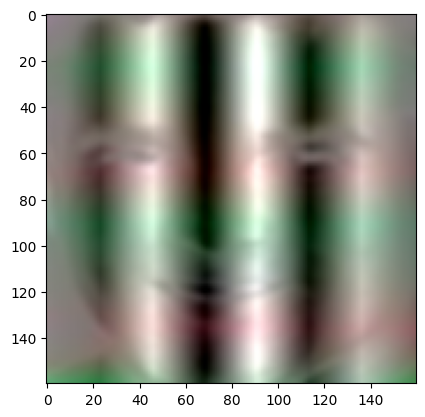

In [20]:
import pylab
pylab.imshow(convert_batch(batch_chunk_stu)[0].permute(1,2,0).cpu().numpy())

In [21]:
shuffled_features_list = torch.cat(shuffled_features_list, dim=0)
original_features_list = torch.cat(original_features_list, dim=0)

In [22]:
original_features_another_list = torch.cat(original_features_another_list, dim=0)

In [23]:
shuffled_features_list.shape, original_features_list.shape

(torch.Size([10122, 512]), torch.Size([10122, 512]))

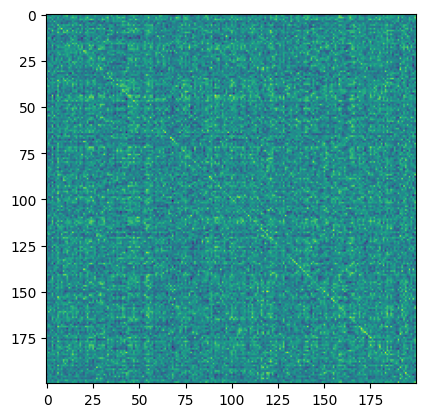

In [24]:
import pylab 
pylab.imshow((shuffled_features_list @ original_features_list.T)[:200,:200].cpu().detach().numpy()) 

In [25]:
image_name

'000191.jpg'

In [26]:
stu = student(convert_batch(preprocess_image(f"{all_root}/{image_name}").to("cuda:1")))[0]
# tea = teacher(preprocess_image(f"{all_root}/"+get_another_image(df, f"001091.jpg")).to("cuda:1"))[0]
tea = teacher(preprocess_image(f"{all_root}/"+get_another_image(df, f"{image_name}")).to("cuda:1"))[0]
stu @ tea 

tensor(0.2725, device='cuda:1', grad_fn=<DotBackward0>)

In [26]:
# Image.open(f"{all_root}/{image_name}").size

In [27]:
# hstack([Image.open(f"{all_root}/{image_name}"), Image.open(f"shuffled_val_another/{image_name}")]) 

In [28]:
# shuffled_features_list = torch.cat(shuffled_features_list, dim=0)
# original_features_list = torch.cat(original_features_list, dim=0)
# shuffled_features_another_list = torch.cat(shuffled_features_another_list, dim=0)
# original_features_another_list = torch.cat(original_features_another_list, dim=0)

In [29]:
# original_features_another_list

In [30]:
# torch.save(shuffled_features_list, "shuffled_features.pt")
# torch.save(original_features_list, "original_features.pt")
# torch.save(shuffled_features_another_list, "shuffled_features_another.pt") 

In [31]:
shuffled_features_list.shape, original_features_list.shape

(torch.Size([5061, 512]), torch.Size([5061, 512]))

In [27]:
rank = []
for i in range(shuffled_features_list.shape[0]):  
    sims = original_features_list[i] @ shuffled_features_list.T 
    prders = torch.argsort(sims, descending=True) 
    rank.append(torch.where(prders == i)[0].item()/len(prders))

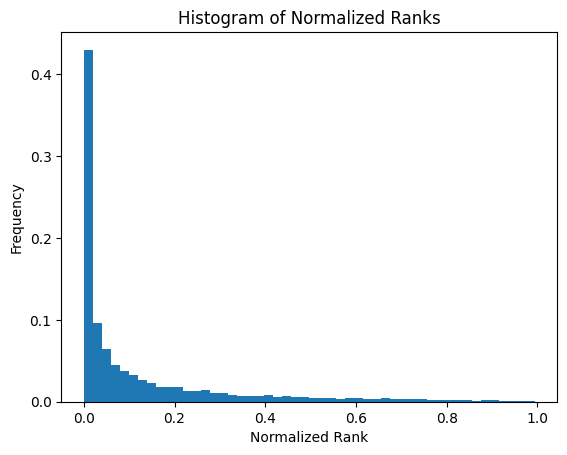

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
counts, bins = np.histogram(rank, bins=50)
rel = counts / counts.sum()
plt.bar(bins[:-1], rel, width=np.diff(bins), align='edge')
pylab.xlabel("Normalized Rank")
pylab.ylabel("Frequency")
pylab.title("Histogram of Normalized Ranks")
plt.show()
 

In [34]:
{
    "recall@0%": sum([1 for r in rank if r <= 0.0]) / len(rank),
    "recall@0.02%": sum([1 for r in rank if r < 0.0002]) / len(rank),
    "recall@0.05%": sum([1 for r in rank if r < 0.0005]) / len(rank),
    "recall@0.1%": sum([1 for r in rank if r < 0.001]) / len(rank),
    "recall@1%": sum([1 for r in rank if r < 0.01]) / len(rank),
    "recall@5%": sum([1 for r in rank if r < 0.05]) / len(rank),
    "mean_rank": sum(rank) / len(rank)
} 

{'recall@0%': 0.08002371072910491,
 'recall@0.02%': 0.1084765856550089,
 'recall@0.05%': 0.12882829480339852,
 'recall@0.1%': 0.17427385892116182,
 'recall@1%': 0.37324639399328197,
 'recall@5%': 0.5848646512546928,
 'mean_rank': 0.1275659635708546}

In [35]:
rank = []
for i in range(shuffled_features_another_list.shape[0]):
    sims = shuffled_features_another_list[i] @ original_features_list.T
    prders = torch.argsort(sims, descending=True)
    rank.append(torch.where(prders == i)[0].item()/len(prders))

AttributeError: 'list' object has no attribute 'shape'

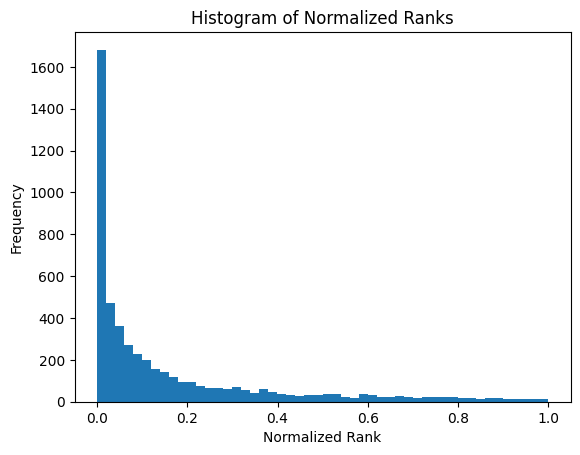

In [ ]:
import pylab
pylab.hist(rank, bins=50)
pylab.xlabel("Normalized Rank")
pylab.ylabel("Frequency")
pylab.title("Histogram of Normalized Ranks")
pylab.show()

In [ ]:
{
    "recall@0%": sum([1 for r in rank if r <= 0.0]) / len(rank),
    "recall@0.02%": sum([1 for r in rank if r <= 0.0002]) / len(rank),
    "recall@0.05%": sum([1 for r in rank if r <= 0.0005]) / len(rank),
    "recall@0.1%": sum([1 for r in rank if r <= 0.001]) / len(rank),
    "recall@1%": sum([1 for r in rank if r <= 0.01]) / len(rank),
    "recall@5%": sum([1 for r in rank if r <= 0.05]) / len(rank),
    "mean_rank": sum(rank) / len(rank)
} 

{'recall@0%': 0.02588421260620431,
 'recall@0.02%': 0.04188895475202529,
 'recall@0.05%': 0.055522623987354275,
 'recall@0.1%': 0.08239478363959692,
 'recall@1%': 0.24836988737403676,
 'recall@5%': 0.4651254692748469,
 'mean_rank': 0.1619189183797238}

In [ ]:
rank = []
for i in range(shuffled_features_list.shape[0]):
    sims = shuffled_features_another_list[i] @ shuffled_features_list.T
    prders = torch.argsort(sims, descending=True)
    rank.append(torch.where(prders == i)[0].item()/len(prders))


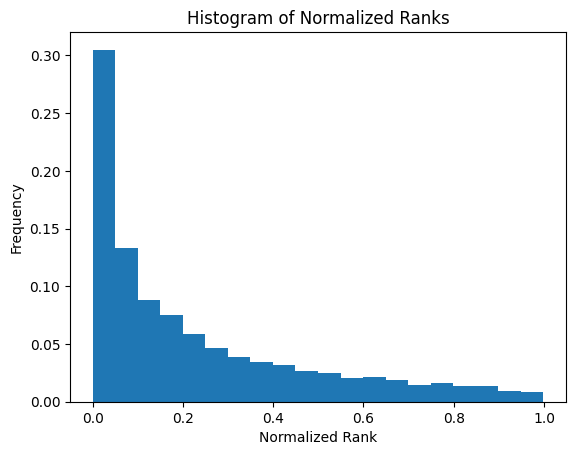

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
counts, bins = np.histogram(rank, bins=20)
rel = counts / counts.sum()
plt.bar(bins[:-1], rel, width=np.diff(bins), align='edge')
pylab.xlabel("Normalized Rank")
pylab.ylabel("Frequency")
pylab.title("Histogram of Normalized Ranks")
plt.show()

In [ ]:
{
    "recall@0%": sum([1 for r in rank if r <= 0.0]) / len(rank),
    "recall@0.02%": sum([1 for r in rank if r <= 0.0002]) / len(rank),
    "recall@0.05%": sum([1 for r in rank if r <= 0.0005]) / len(rank),
    "recall@0.1%": sum([1 for r in rank if r <= 0.001]) / len(rank),
    "recall@1%": sum([1 for r in rank if r <= 0.01]) / len(rank),
    "recall@5%": sum([1 for r in rank if r <= 0.05]) / len(rank),
    "mean_rank": sum(rank) / len(rank)
} 

{'recall@0%': 0.009681881051175657,
 'recall@0.02%': 0.015609563327405651,
 'recall@0.05%': 0.021142066785220313,
 'recall@0.1%': 0.03339261015609563,
 'recall@1%': 0.12507409602845287,
 'recall@5%': 0.3052756372258447,
 'mean_rank': 0.2313570527296688}

In [30]:
original_features_another_list

tensor([[ 0.0621, -0.0314,  0.0638,  ...,  0.0724, -0.0427, -0.0748],
        [-0.0233,  0.0301,  0.0474,  ..., -0.0307, -0.0262,  0.0258],
        [ 0.0189, -0.0142, -0.0073,  ...,  0.0006,  0.0777, -0.0117],
        ...,
        [-0.0248,  0.0659,  0.0827,  ..., -0.0325,  0.0524,  0.0215],
        [ 0.0270, -0.0531, -0.0253,  ..., -0.0141,  0.0138, -0.0459],
        [-0.0834,  0.1047, -0.0229,  ...,  0.0551,  0.0709, -0.0133]])

In [31]:
rank = []
for i in range(len(original_features_another_list)):
    sims = original_features_list[i].cpu() @ original_features_another_list.T
    # sims = original_features_another_list[i].cpu() @ original_features_list.T
    prders = torch.argsort(sims, descending=True)
    rank.append(torch.where(prders == i)[0].item()/len(prders))


In [32]:
np.where(np.array(rank) > 0.1)

(array([   37,    39,    40,    46,    49,    72,    84,    89,    95,
          103,   110,   118,   121,   136,   180,   220,   237,   248,
          252,   293,   329,   345,   352,   364,   377,   417,   453,
          499,   519,   522,   534,   541,   612,   681,   692,   729,
          813,   829,   830,   831,   842,   847,   861,   893,   919,
          925,   929,   968,   972,   975,  1007,  1034,  1035,  1075,
         1088,  1133,  1137,  1148,  1158,  1175,  1257,  1287,  1314,
         1360,  1369,  1373,  1377,  1388,  1389,  1392,  1408,  1430,
         1440,  1455,  1458,  1472,  1550,  1598,  1606,  1646,  1650,
         1690,  1692,  1715,  1719,  1755,  1760,  1762,  1785,  1826,
         1835,  1864,  1879,  1881,  1893,  1902,  1904,  1906,  1911,
         1924,  1942,  1955,  1975,  2072,  2122,  2137,  2171,  2244,
         2319,  2333,  2372,  2408,  2424,  2440,  2450,  2467,  2492,
         2507,  2545,  2548,  2558,  2566,  2598,  2639,  2662,  2672,
      

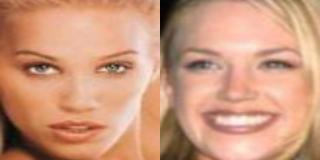

In [ ]:
hstack([Image.open(f"val/{os.listdir('shuffled_val')[23]}"), Image.open(f"{all_root}/"+get_another_image(df, os.listdir('shuffled_val')[23]))]) 


2025-11-24 02:56:04,829: Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


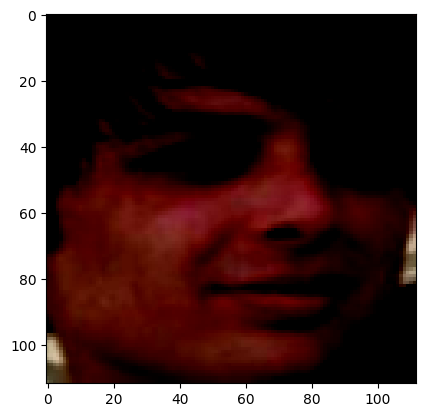

In [ ]:
pylab.imshow(batch_tea_another[7][0].permute(1,2,0).cpu().numpy()) 

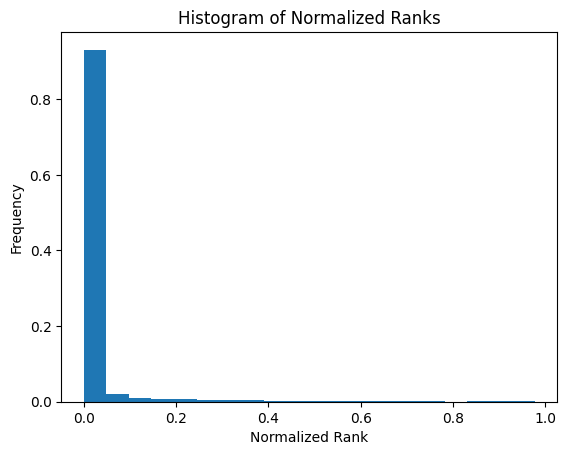

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
counts, bins = np.histogram(rank, bins=20)
rel = counts / counts.sum()
plt.bar(bins[:-1], rel, width=np.diff(bins), align='edge')
pylab.xlabel("Normalized Rank")
pylab.ylabel("Frequency")
pylab.title("Histogram of Normalized Ranks")
plt.show()

In [ ]:
{
    "recall@0%": sum([1 for r in rank if r <= 0.0]) / len(rank),
    "recall@0.02%": sum([1 for r in rank if r <= 0.0002]) / len(rank),
    "recall@0.05%": sum([1 for r in rank if r <= 0.0005]) / len(rank),
    "recall@0.1%": sum([1 for r in rank if r <= 0.001]) / len(rank),
    "recall@1%": sum([1 for r in rank if r <= 0.01]) / len(rank),
    "recall@5%": sum([1 for r in rank if r <= 0.05]) / len(rank),
    "mean_rank": sum(rank) / len(rank) 
}  

{'recall@0%': 0.3018178225647105,
 'recall@0.02%': 0.6371270499901205,
 'recall@0.05%': 0.6998616874135546,
 'recall@0.1%': 0.7462951985773563,
 'recall@1%': 0.8755186721991701,
 'recall@5%': 0.9316340644141474,
 'mean_rank': 0.021269156871037326}

In [ ]:
# from insightface.app import FaceAnalysis
# import torch

# app = FaceAnalysis(name='arcface_r100_v1')
# app.prepare(ctx_id=0, det_size=(640,640))

# model = app.models['recognition']
# torch_model = model.model
# torch_model.eval()

download_path: /home/user/.insightface/models/arcface_r100_v1


RuntimeError: Failed downloading url https://github.com/deepinsight/insightface/releases/download/v0.7/arcface_r100_v1.zip

In [ ]:
# import torch
# import sys
# sys.path.append('InsightFace_Pytorch')
# from model import Backbone  

/home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
